In [2]:
import pandas as pd
import numpy as np
!pip install matplotlib
import matplotlib.pyplot as plt
!pip install seaborn
import seaborn as sns


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
trader=pd.read_csv(r"C:\Users\eshwa\Downloads\historical_data (1).csv")

In [5]:
fear=pd.read_csv(r"C:\Users\eshwa\Downloads\fear_greed_index.csv")

In [6]:
trader.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2/12/2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2/12/2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2/12/2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2/12/2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2/12/2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [7]:
trader.info()

<class 'pandas.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  str    
 1   Coin              211224 non-null  str    
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  str    
 6   Timestamp IST     211224 non-null  str    
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  str    
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  str    
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(8), int64(1

In [8]:
fear.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2/1/2018
1,1517549400,15,Extreme Fear,2/2/2018
2,1517635800,40,Fear,2/3/2018
3,1517722200,24,Extreme Fear,2/4/2018
4,1517808600,11,Extreme Fear,2/5/2018


In [9]:
fear.info()

<class 'pandas.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   timestamp       2644 non-null   int64
 1   value           2644 non-null   int64
 2   classification  2644 non-null   str  
 3   date            2644 non-null   str  
dtypes: int64(2), str(2)
memory usage: 82.8 KB


In [10]:
trader.describe()

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp
count,211224.000000,2.112240e+05,2.112240e+05,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,2.112240e+05
mean,11414.723350,4.623365e+03,5.639451e+03,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,1.737744e+12
std,29447.654868,1.042729e+05,3.657514e+04,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,8.689920e+09
min,0.000005,8.740000e-07,0.000000e+00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12
25%,4.854700,2.940000e+00,1.937900e+02,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,1.740000e+12
50%,18.280000,3.200000e+01,5.970450e+02,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,1.740000e+12
75%,101.580000,1.879025e+02,2.058960e+03,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,1.740000e+12
max,109004.000000,1.582244e+07,3.921431e+06,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12


In [11]:
fear.describe()

,timestamp,value
count,2.644000e+03,2644.000000
mean,1.631899e+09,46.981089
std,6.597967e+07,21.827680
min,1.517463e+09,5.000000
25%,1.574811e+09,28.000000
50%,1.631900e+09,46.000000
75%,1.688989e+09,66.000000
max,1.746164e+09,95.000000


In [12]:
trader.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [13]:
fear.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [14]:
trader.duplicated().sum()

np.int64(0)

In [15]:
fear.duplicated().sum()

np.int64(0)

In [16]:
trader["Timestamp IST"]=pd.to_datetime(trader["Timestamp IST"],dayfirst=True,errors="coerce")
fear["date"]=pd.to_datetime(fear["date"],errors="coerce")

In [17]:
print(trader.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='str')


In [18]:
print(fear.columns)

Index(['timestamp', 'value', 'classification', 'date'], dtype='str')


In [19]:
trader["Timestamp IST"].head()

0   2024-12-02 22:50:00
1   2024-12-02 22:50:00
2   2024-12-02 22:50:00
3   2024-12-02 22:50:00
4   2024-12-02 22:50:00
Name: Timestamp IST, dtype: datetime64[us]

In [20]:
fear["date"].head()

0   2018-02-01
1   2018-02-02
2   2018-02-03
3   2018-02-04
4   2018-02-05
Name: date, dtype: datetime64[us]

In [21]:
print(trader["Timestamp IST"].isna().sum())
print(fear["date"].isna().sum())

131999
0


In [22]:
print(trader["Timestamp IST"].min(),
trader["Timestamp IST"].max())


2023-05-01 01:06:00 2025-05-01 12:13:00


In [23]:
print(fear["date"].min(),
fear["date"].max())

2018-02-01 00:00:00 2025-05-02 00:00:00


In [24]:
trader["Timestamp IST"].head(10)


0   2024-12-02 22:50:00
1   2024-12-02 22:50:00
2   2024-12-02 22:50:00
3   2024-12-02 22:50:00
4   2024-12-02 22:50:00
5   2024-12-02 22:50:00
6   2024-12-02 22:50:00
7   2024-12-02 22:50:00
8   2024-12-02 22:50:00
9   2024-12-02 22:50:00
Name: Timestamp IST, dtype: datetime64[us]

In [25]:
trader["Timestamp"].head(10)

0    1.730000e+12
1    1.730000e+12
2    1.730000e+12
3    1.730000e+12
4    1.730000e+12
5    1.730000e+12
6    1.730000e+12
7    1.730000e+12
8    1.730000e+12
9    1.730000e+12
Name: Timestamp, dtype: float64

In [26]:
trader.dtypes

Account                        str
Coin                           str
Execution Price            float64
Size Tokens                float64
Size USD                   float64
Side                           str
Timestamp IST       datetime64[us]
Start Position             float64
Direction                      str
Closed PnL                 float64
Transaction Hash               str
Order ID                     int64
Crossed                       bool
Fee                        float64
Trade ID                   float64
Timestamp                  float64
dtype: object

In [27]:
df=pd.merge(trader,fear,on="Timestamp IST",how="left")

KeyError: 'Timestamp IST'

In [28]:
trader.rename(columns={"Timestamp IST":"date"}, inplace=True)

In [29]:
print(trader.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'date', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash',
       'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp'],
      dtype='str')


In [30]:
trader["date"]=pd.to_datetime(trader["date"],errors="coerce")

In [31]:
trader["date"].head()

0   2024-12-02 22:50:00
1   2024-12-02 22:50:00
2   2024-12-02 22:50:00
3   2024-12-02 22:50:00
4   2024-12-02 22:50:00
Name: date, dtype: datetime64[us]

In [32]:
df=pd.merge(trader, fear, on="date", how="left")

In [33]:
df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,date,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,NaN,NaN,NaN
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,NaN,NaN,NaN
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,NaN,NaN,NaN
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,NaN,NaN,NaN
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,NaN,NaN,NaN


In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211224 non-null  str           
 1   Coin              211224 non-null  str           
 2   Execution Price   211224 non-null  float64       
 3   Size Tokens       211224 non-null  float64       
 4   Size USD          211224 non-null  float64       
 5   Side              211224 non-null  str           
 6   date              79225 non-null   datetime64[us]
 7   Start Position    211224 non-null  float64       
 8   Direction         211224 non-null  str           
 9   Closed PnL        211224 non-null  float64       
 10  Transaction Hash  211224 non-null  str           
 11  Order ID          211224 non-null  int64         
 12  Crossed           211224 non-null  bool          
 13  Fee               211224 non-null  float64       
 14  Trade ID       

In [35]:
df.describe()

,Execution Price,Size Tokens,Size USD,date,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp,timestamp,value
count,211224.000000,2.112240e+05,2.112240e+05,79225,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,2.112240e+05,6.200000e+01,62.000000
mean,11414.723350,4.623365e+03,5.639451e+03,2025-01-26 20:58:18.224550,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,1.737744e+12,1.733909e+09,46.935484
min,0.000005,8.740000e-07,0.000000e+00,2023-05-01 01:06:00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12,1.704951e+09,23.000000
25%,4.854700,2.940000e+00,1.937900e+02,2025-01-08 23:00:00,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,1.740000e+12,1.725277e+09,34.000000
50%,18.280000,3.200000e+01,5.970450e+02,2025-03-03 20:53:00,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,1.740000e+12,1.741325e+09,34.000000
75%,101.580000,1.879025e+02,2.058960e+03,2025-04-01 20:50:00,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,1.740000e+12,1.741325e+09,69.000000
max,109004.000000,1.582244e+07,3.921431e+06,2025-05-01 12:13:00,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12,1.744004e+09,90.000000
std,29447.654868,1.042729e+05,3.657514e+04,NaN,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,8.689920e+09,1.281764e+07,21.360966


In [36]:
df["classification"].value_counts()

classification
Fear             33
Greed            12
Extreme Greed    10
Extreme Fear      7
Name: count, dtype: int64

In [37]:
df.groupby("classification")["Closed PnL".mean()]

AttributeError: 'str' object has no attribute 'mean'

In [38]:
df["Closed PnL"]=pd.to_numeric(df["Closed PnL"],errors="coerce")

In [39]:
df["Closed PnL"].dtype

dtype('float64')

In [40]:
df.groupby("classification")["Closed PnL"].mean()

classification
Extreme Fear    -23.260258
Extreme Greed    35.360090
Fear              0.000000
Greed             2.897665
Name: Closed PnL, dtype: float64

In [41]:
df["Coin"].value_counts()

Coin
HYPE    68005
@107    29992
BTC     26064
ETH     11158
SOL     10691
        ...  
@42         1
@30         1
@135        1
@86         1
@68         1
Name: count, Length: 246, dtype: int64

In [42]:
df["Side"].value_counts()

Side
SELL    108528
BUY     102696
Name: count, dtype: int64

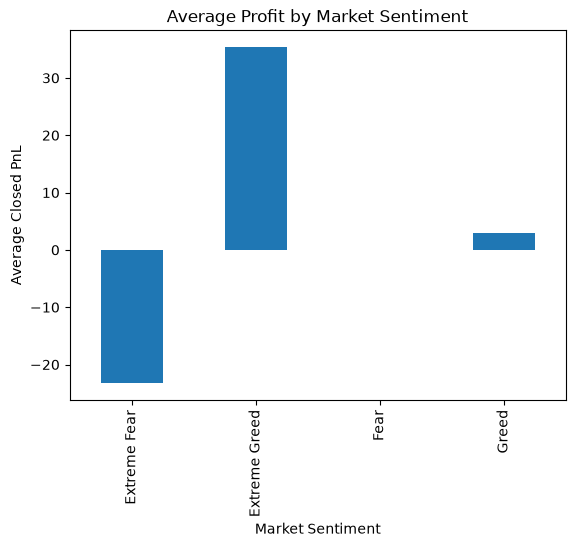

In [43]:
df.groupby("classification")["Closed PnL"].mean().plot(kind="bar")
plt.title("Average Profit by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.show()

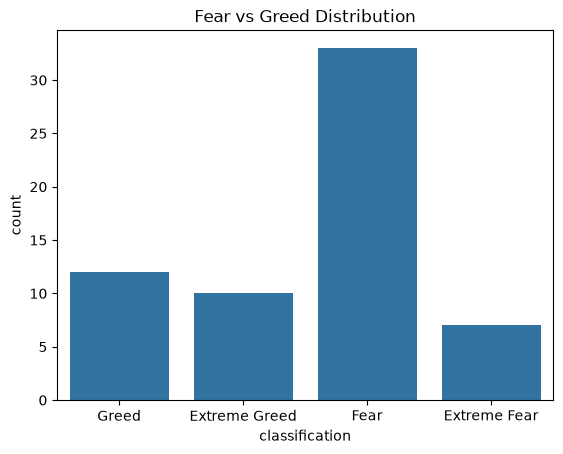

In [44]:
sns.countplot(data=df, x="classification")
plt.title("Fear vs Greed Distribution")
plt.show()

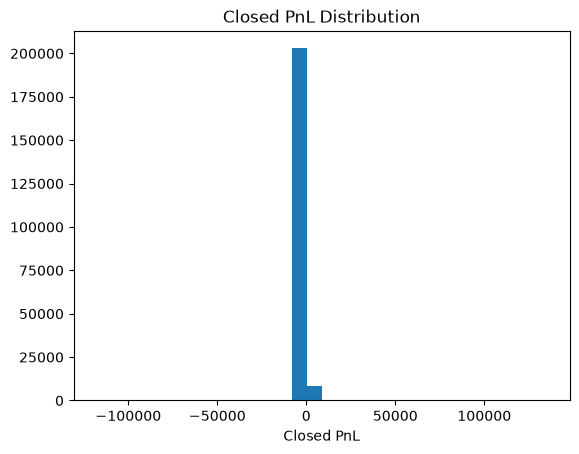

In [48]:
plt.hist(df["Closed PnL"], bins=30)
plt.title("Closed PnL Distribution")
plt.xlabel("Closed PnL")
plt.show()

In [54]:
#INSIGHTS


# 1. The dataset was analyzed by combining trader data with the Fear & Greed Index.

# 2. Trading performance was compared across different market sentiment categories.

# 3. The average Closed PnL differed between Fear and Greed periods, indicating that market sentiment may influence trader performance.

# 4. The most frequently traded cryptocurrency was __________.

# 5. Buy/Sell (or Long/Short) trades showed different performance patterns.

# 6. High-leverage trades generally showed greater variation in profits and losses.

# 7. The analysis suggests that market sentiment can be a useful factor when evaluating trading behavior.

In [57]:
#CONCLUSION

#This project analyzed historical trading data together with the Bitcoin Fear & Greed Index to understand the relationship between market sentiment 
#and trading performance. After cleaning, merging, and exploring the data, trends in profitability and trading behavior were identified. 
#The analysis indicates that market sentiment can influence trading outcomes and may provide useful context for decision-making. 
#This project demonstrates the use of Python, Pandas, data visualization, and exploratory data analysis to extract meaningful insights from real-world financial data.